In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("sales_data.csv")
data.head(10)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
5,1021,2023-02-11,Charlie,West,3761.15,32,Food,900.79,1106.51,New,0.21,Cash,Online,West-Charlie
6,1083,2023-04-11,Bob,West,618.31,29,Furniture,2408.81,2624.09,Returning,0.14,Cash,Online,West-Bob
7,1087,2023-01-06,Eve,South,7698.92,46,Furniture,3702.51,3964.65,New,0.12,Bank Transfer,Online,South-Eve
8,1075,2023-06-29,David,South,4223.39,30,Furniture,738.06,1095.45,New,0.05,Bank Transfer,Online,South-David
9,1075,2023-10-09,Charlie,West,8239.58,18,Clothing,2228.35,2682.34,New,0.13,Bank Transfer,Online,West-Charlie


In [3]:
selected_columns = ['Sales_Amount', 'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price', 'Discount']
data[selected_columns].describe()

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,100.120000,1.000000,60.280000,167.120000,0.00000
25%,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,9989.040000,49.000000,4995.300000,5442.150000,0.30000


Text(0.5, 1.02, 'Pairplot of Selected Sales Data Features')

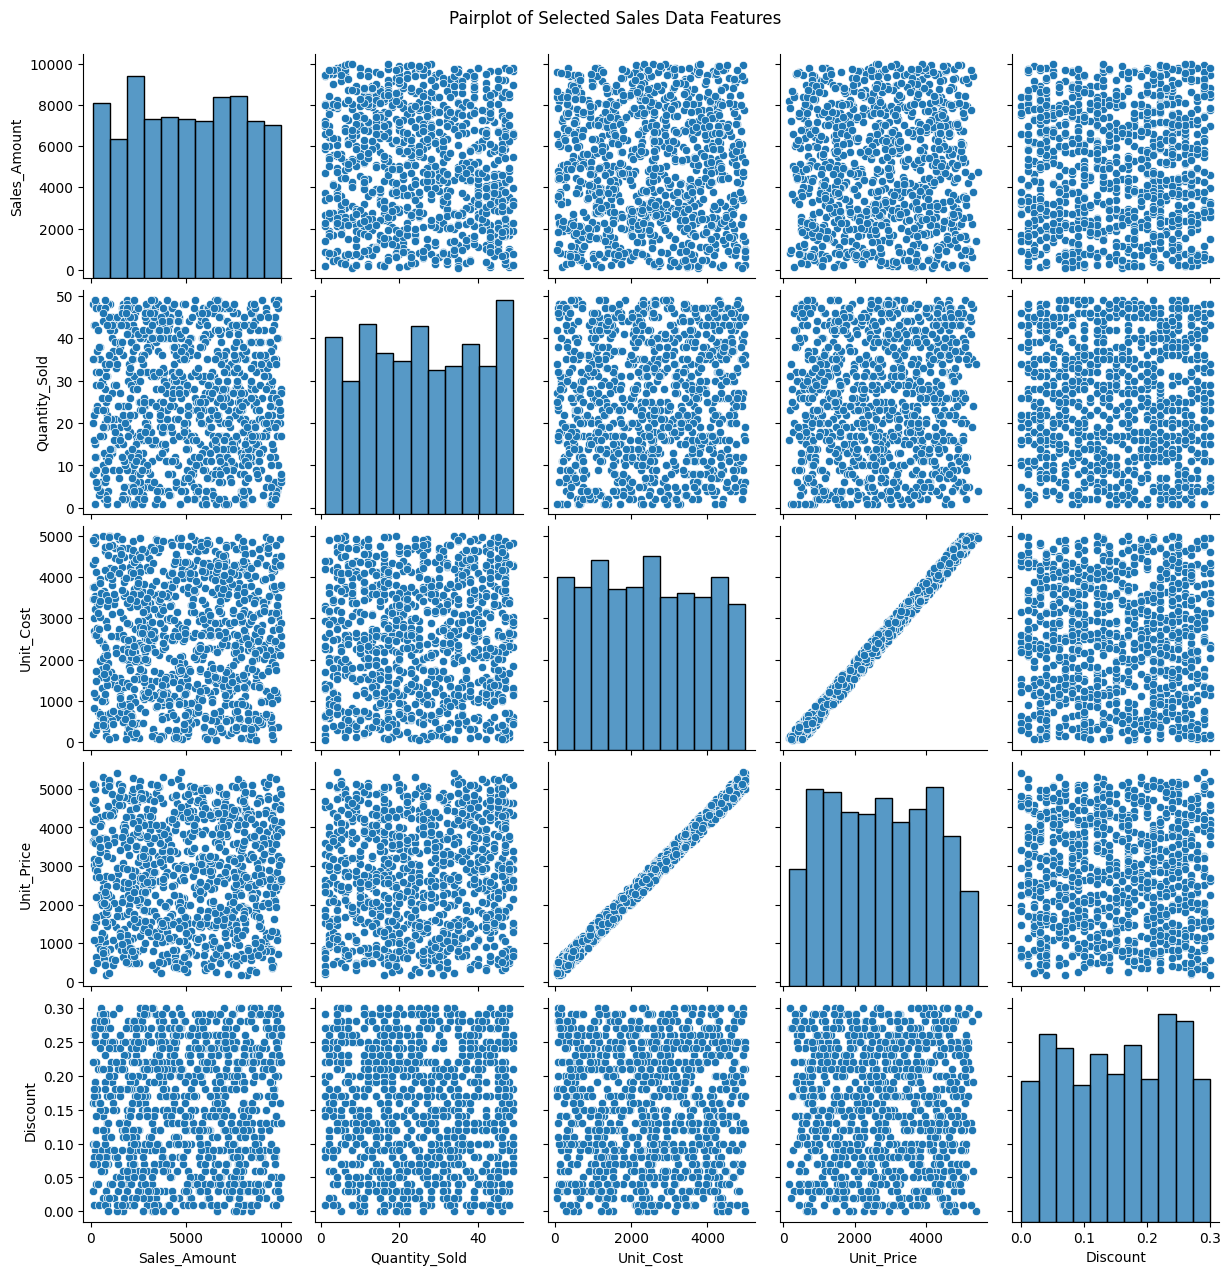

In [4]:
sns.pairplot(data[selected_columns])
plt.suptitle('Pairplot of Selected Sales Data Features', y=1.02)

In [5]:
data['Total_Cost'] = data['Quantity_Sold'] * data['Unit_Cost']
data['Total_Revenue'] = data['Quantity_Sold'] * data['Unit_Price']
data['Total_Revenue_After_Discount'] = data['Total_Revenue'] * (1 - data['Discount'])
data['Total_Profit'] = data['Total_Revenue'] - data['Total_Cost']
data['Unit_Sales'] = data['Sales_Amount'] / data['Quantity_Sold']
data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Total_Cost,Total_Revenue,Total_Revenue_After_Discount,Total_Profit,Unit_Sales
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2749.50,4809.96,4377.0636,2060.46,280.776111
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,64878.63,71560.48,63688.8272,6681.85,257.883529
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,7846.80,11142.00,8913.6000,3295.20,154.374333
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,168871.17,174242.25,170757.4050,5371.08,55.588205
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,8285.81,9005.23,8284.8116,719.42,288.476923


<Axes: title={'center': 'Proportion of Profitable Sales Transactions\n Margin after Discount vs Cost'}, ylabel='count'>

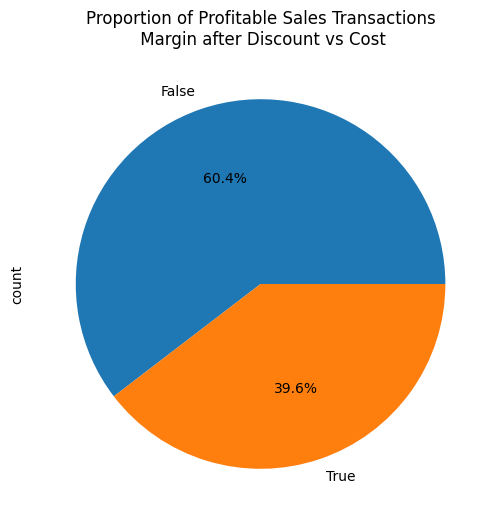

In [6]:
(
    data['Unit_Cost'] < data['Unit_Price'] * (1 - data['Discount'])
).value_counts().plot(kind='pie', figsize=(6, 6), autopct='%1.1f%%', title='Proportion of Profitable Sales Transactions\n Margin after Discount vs Cost')

<Axes: title={'center': 'Proportion of Sales Above Unit Price\n Sales Price vs Unit Price'}, ylabel='count'>

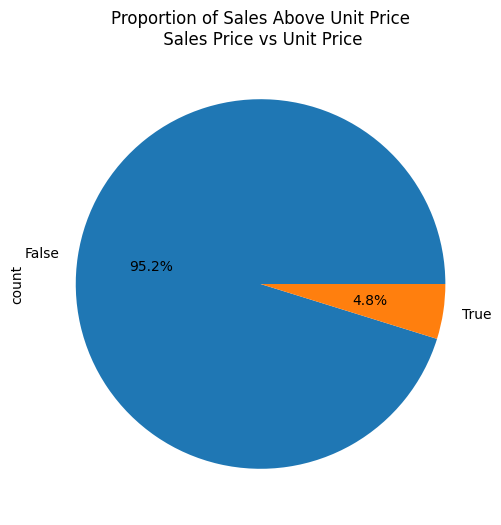

In [7]:
(
    data['Unit_Price'] < data['Unit_Sales']
).value_counts().plot(kind='pie', figsize=(6, 6), autopct='%1.1f%%', title='Proportion of Sales Above Unit Price\n Sales Price vs Unit Price')

In [37]:
data['Profit_Margin'] = data['Total_Profit'] / data['Total_Revenue']
data['Is_Profitable'] = data['Unit_Cost'] < data['Unit_Price'] * (1 - data['Discount'])
data['Above_Unit_Price'] = data['Unit_Price'] < data['Unit_Sales']
data['Unit_Price_After_Discount'] = data['Unit_Price'] * (1 - data['Discount'])

data['Profit_Status'] = np.where(
    data['Is_Profitable'] & data['Above_Unit_Price'],
    'Profitable & Above Unit Price',
    np.where(
        data['Is_Profitable'] & ~data['Above_Unit_Price'],
        'Profitable & Below Unit Price',
        np.where(
            ~data['Is_Profitable'] & data['Above_Unit_Price'],
            'Not Profitable & Above Unit Price',
            'Not Profitable & Below Unit Price'
        )
    )
)
data.head(10)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,...,Total_Cost,Total_Revenue,Total_Revenue_After_Discount,Total_Profit,Unit_Sales,Profit_Margin,Is_Profitable,Above_Unit_Price,Unit_Price_After_Discount,Profit_Status
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,...,2749.50,4809.96,4377.0636,2060.46,280.776111,0.428374,True,True,243.1702,Profitable & Above Unit Price
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,...,64878.63,71560.48,63688.8272,6681.85,257.883529,0.093373,False,False,3746.4016,Not Profitable & Below Unit Price
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,...,7846.80,11142.00,8913.6000,3295.20,154.374333,0.295746,True,False,297.1200,Profitable & Below Unit Price
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,...,168871.17,174242.25,170757.4050,5371.08,55.588205,0.030825,True,False,4378.3950,Profitable & Below Unit Price
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,...,8285.81,9005.23,8284.8116,719.42,288.476923,0.079889,False,False,637.2932,Not Profitable & Below Unit Price
5,1021,2023-02-11,Charlie,West,3761.15,32,Food,900.79,1106.51,New,...,28825.28,35408.32,27972.5728,6583.04,117.535938,0.185918,False,False,874.1429,Not Profitable & Below Unit Price
6,1083,2023-04-11,Bob,West,618.31,29,Furniture,2408.81,2624.09,Returning,...,69855.49,76098.61,65444.8046,6243.12,21.321034,0.082040,False,False,2256.7174,Not Profitable & Below Unit Price
7,1087,2023-01-06,Eve,South,7698.92,46,Furniture,3702.51,3964.65,New,...,170315.46,182373.90,160489.0320,12058.44,167.367826,0.066119,False,False,3488.8920,Not Profitable & Below Unit Price
8,1075,2023-06-29,David,South,4223.39,30,Furniture,738.06,1095.45,New,...,22141.80,32863.50,31220.3250,10721.70,140.779667,0.326249,True,False,1040.6775,Profitable & Below Unit Price
9,1075,2023-10-09,Charlie,West,8239.58,18,Clothing,2228.35,2682.34,New,...,40110.30,48282.12,42005.4444,8171.82,457.754444,0.169251,True,False,2333.6358,Profitable & Below Unit Price


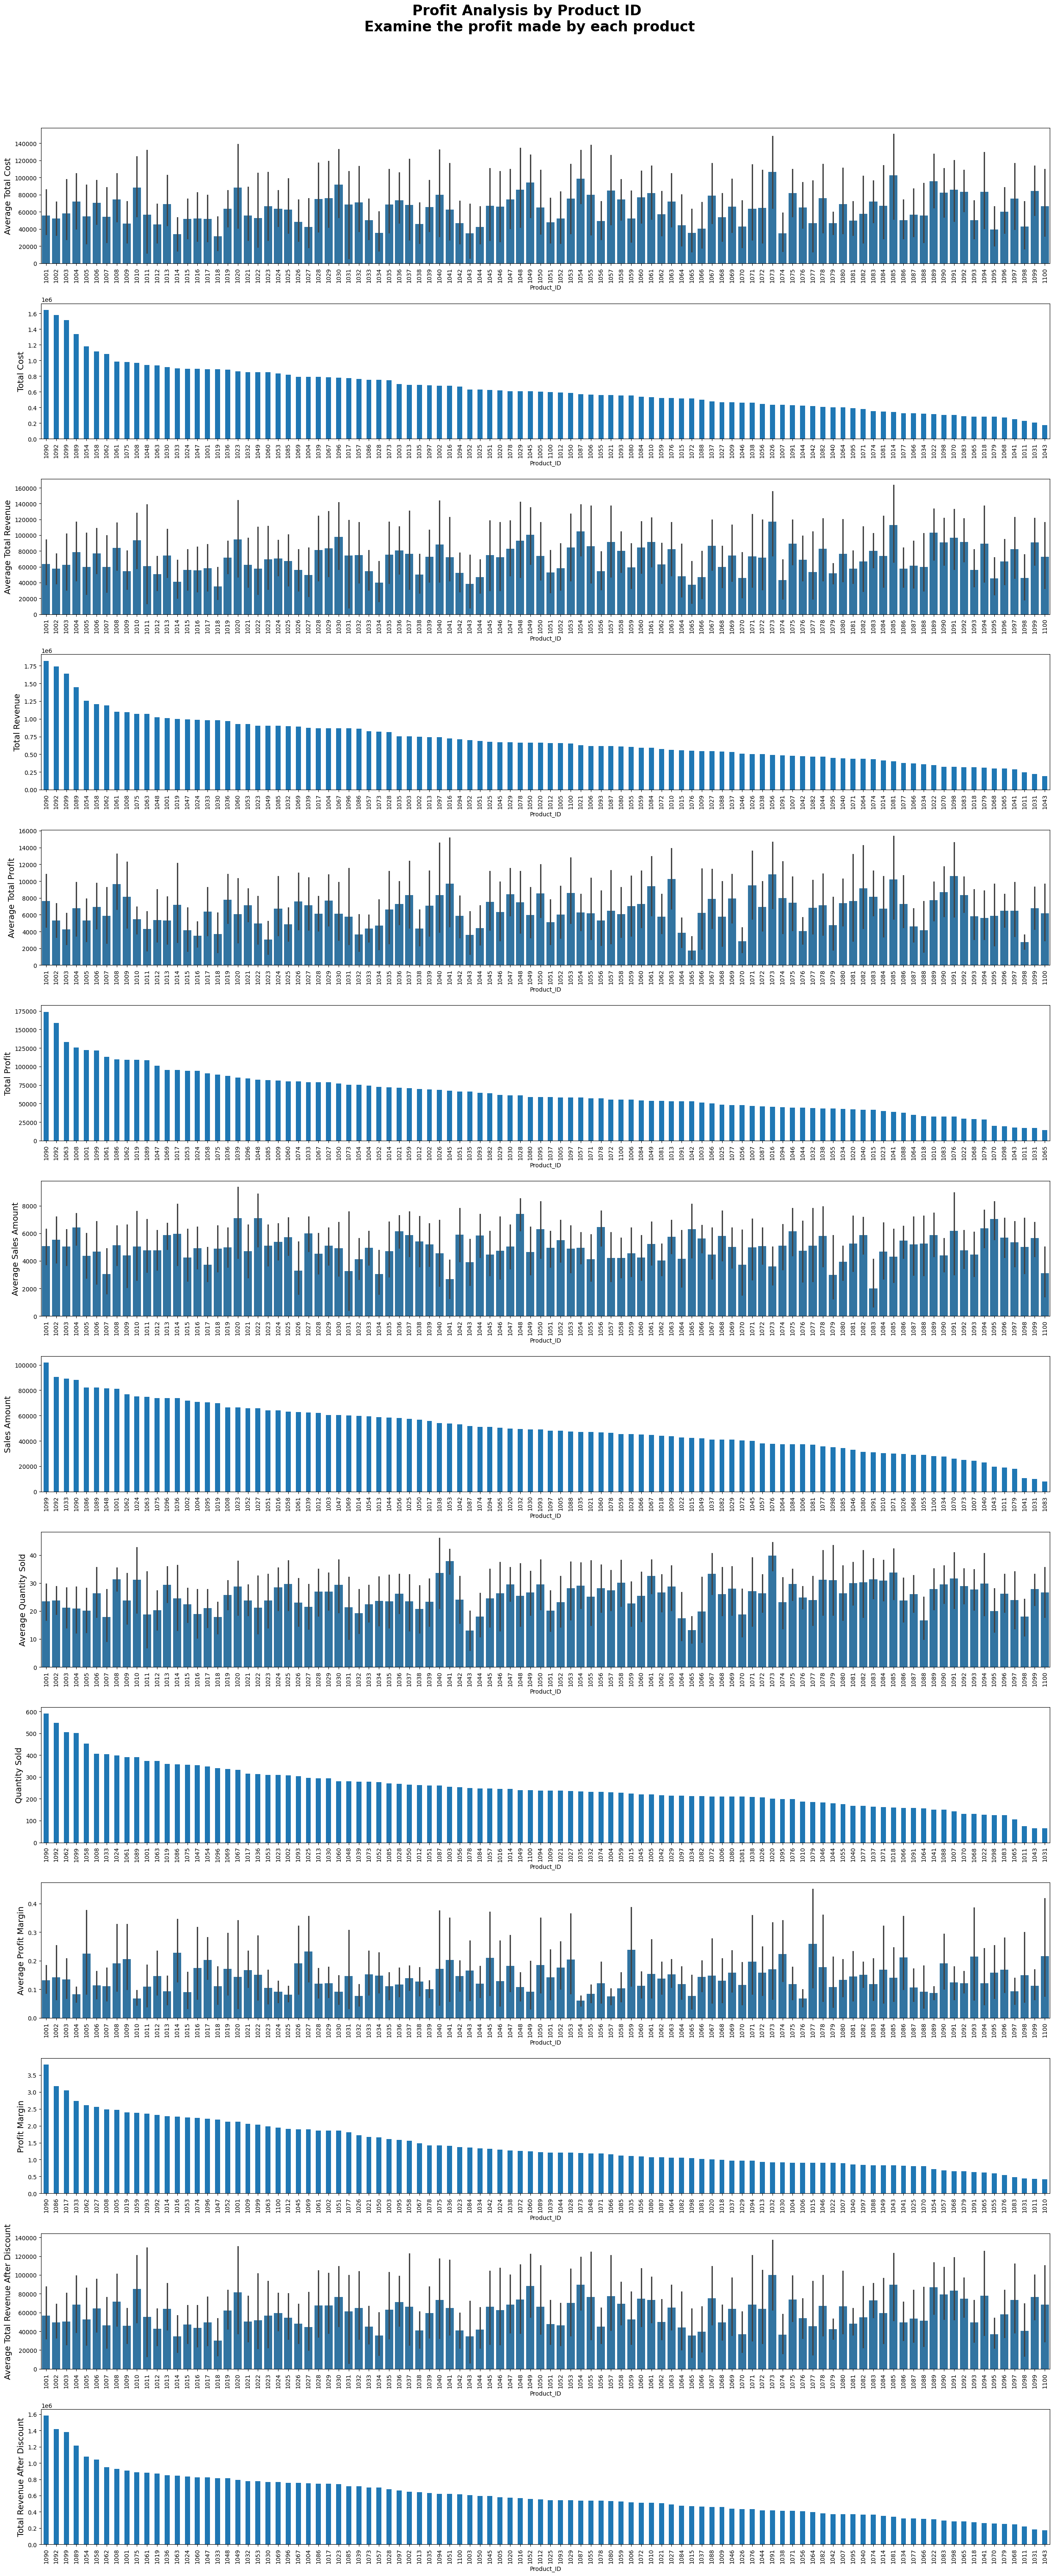

In [9]:
selected_columns = ['Total_Cost', 'Total_Revenue', 'Total_Profit', 'Sales_Amount', 'Quantity_Sold', 'Profit_Margin', 'Total_Revenue_After_Discount']

fig, ax = plt.subplots(len(selected_columns) * 2, 1, figsize=(25, 64))

plt.suptitle('Profit Analysis by Product ID\n Examine the profit made by each product', fontsize=24, fontweight='bold')
for i, key in enumerate(selected_columns):
    i = i * 2

    key_name = "Average " + key.replace('_', ' ').title()
    sns.barplot(data=data, x='Product_ID', y=key, ax=ax[i])
    ax[i].set_ylabel(ylabel=key_name, fontsize=14)
    ax[i].tick_params(axis='x', rotation=90)

    key_name = key.replace('_', ' ').title()
    data.groupby('Product_ID')[key].sum().sort_values(ascending=False).plot(kind='bar', ax=ax[i+1])
    ax[i+1].set_ylabel(ylabel=key_name, fontsize=14)
    ax[i+1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

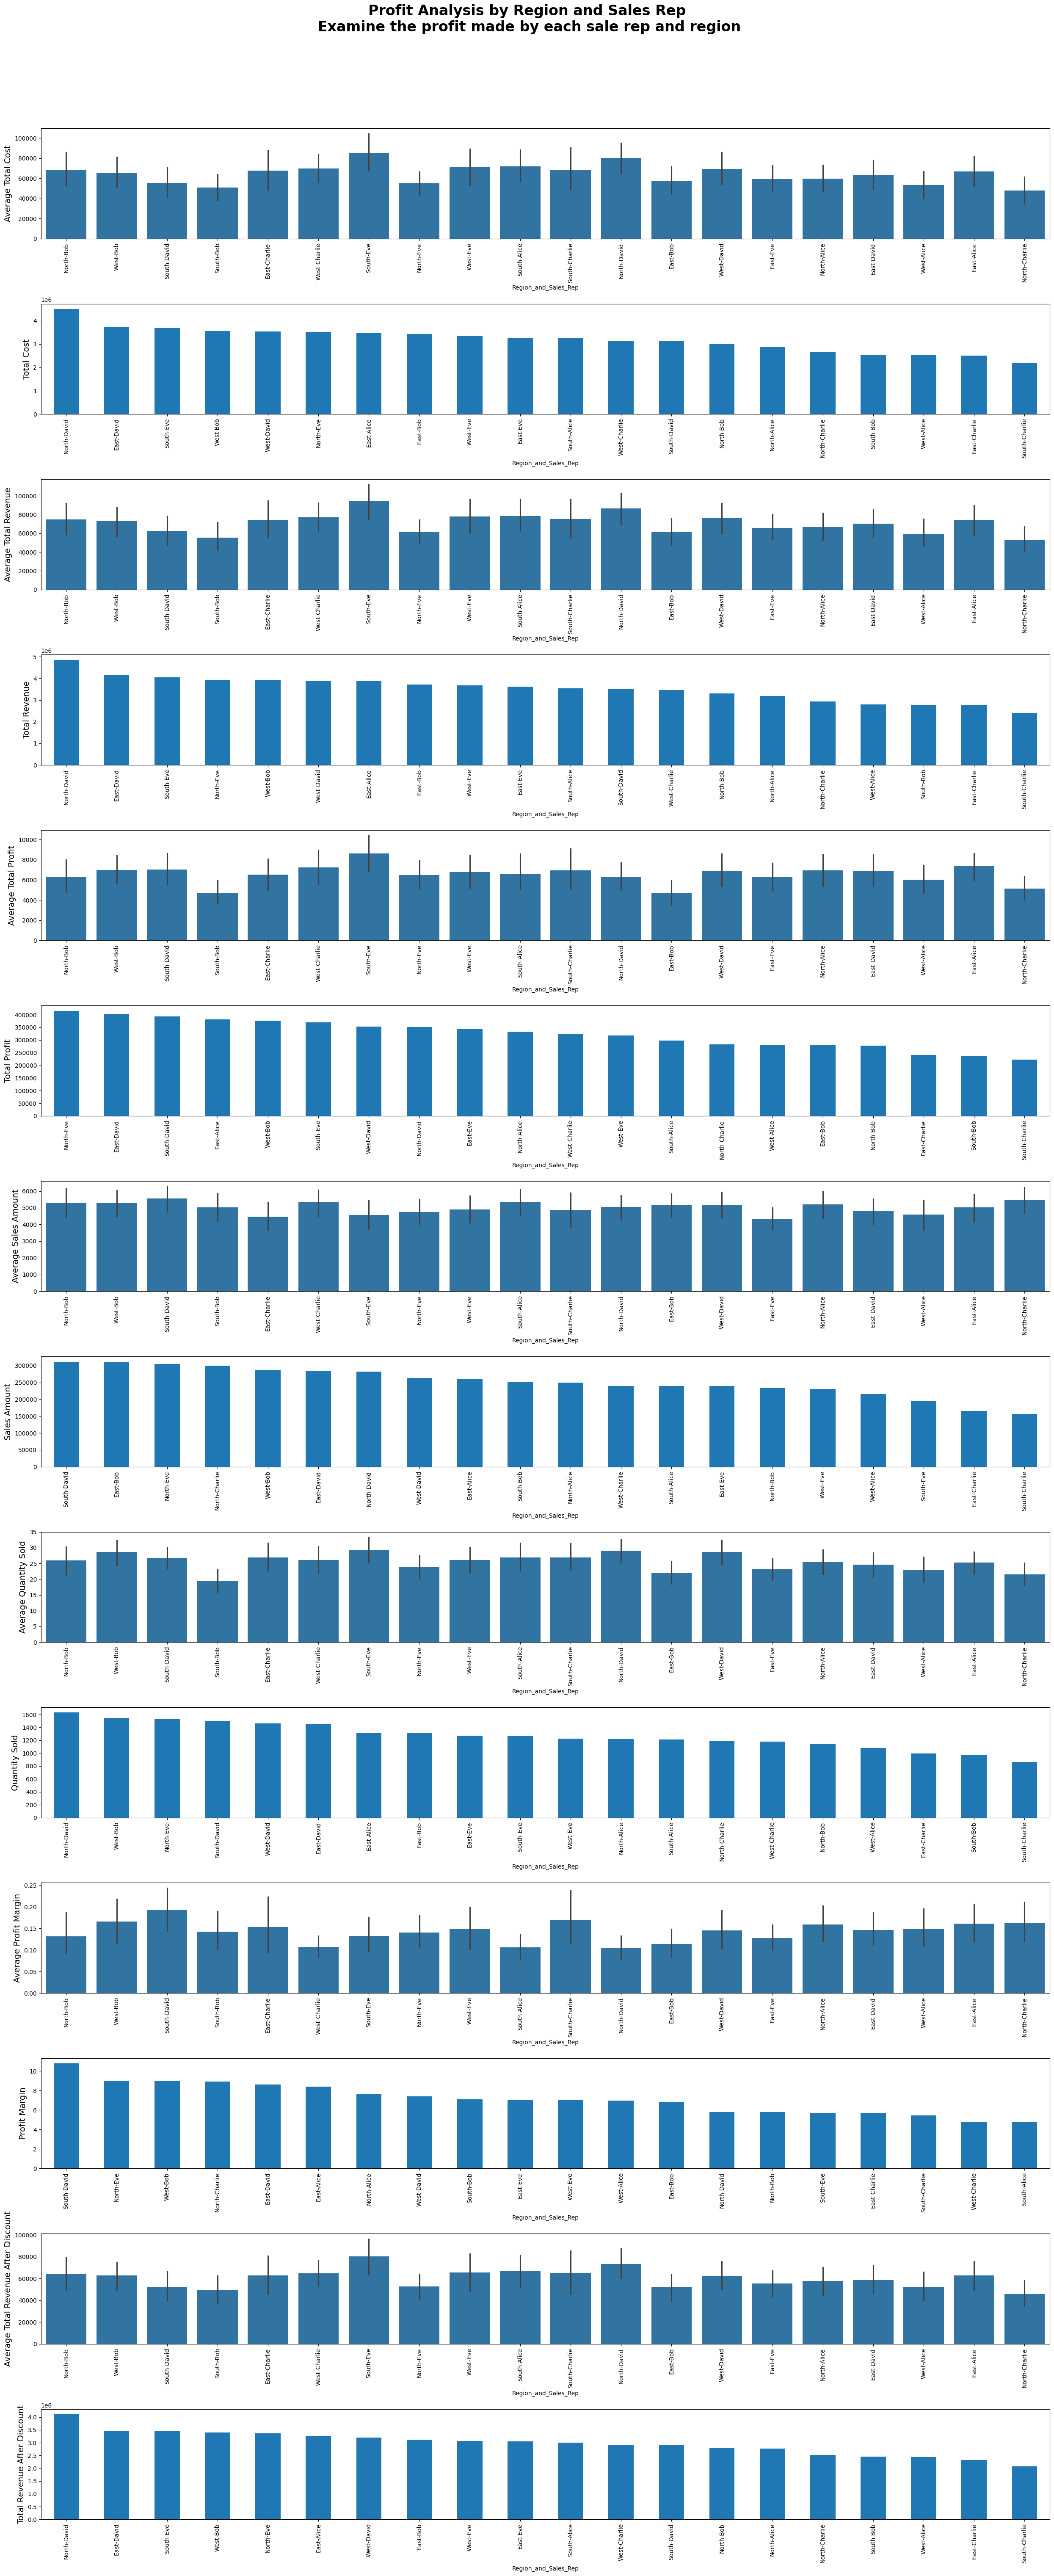

In [10]:
fig, ax = plt.subplots(len(selected_columns) * 2, 1, figsize=(25, 64))

plt.suptitle('Profit Analysis by Region and Sales Rep\n Examine the profit made by each sale rep and region', fontsize=24, fontweight='bold')
for i, key in enumerate(selected_columns):
    i = i * 2

    key_name = "Average " + key.replace('_', ' ').title()
    sns.barplot(data=data, x='Region_and_Sales_Rep', y=key, ax=ax[i])
    ax[i].set_ylabel(ylabel=key_name, fontsize=14)
    ax[i].tick_params(axis='x', rotation=90)

    key_name = key.replace('_', ' ').title()
    data.groupby('Region_and_Sales_Rep')[key].sum().sort_values(ascending=False).plot(kind='bar', ax=ax[i+1])
    ax[i+1].set_ylabel(ylabel=key_name, fontsize=14)
    ax[i+1].tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

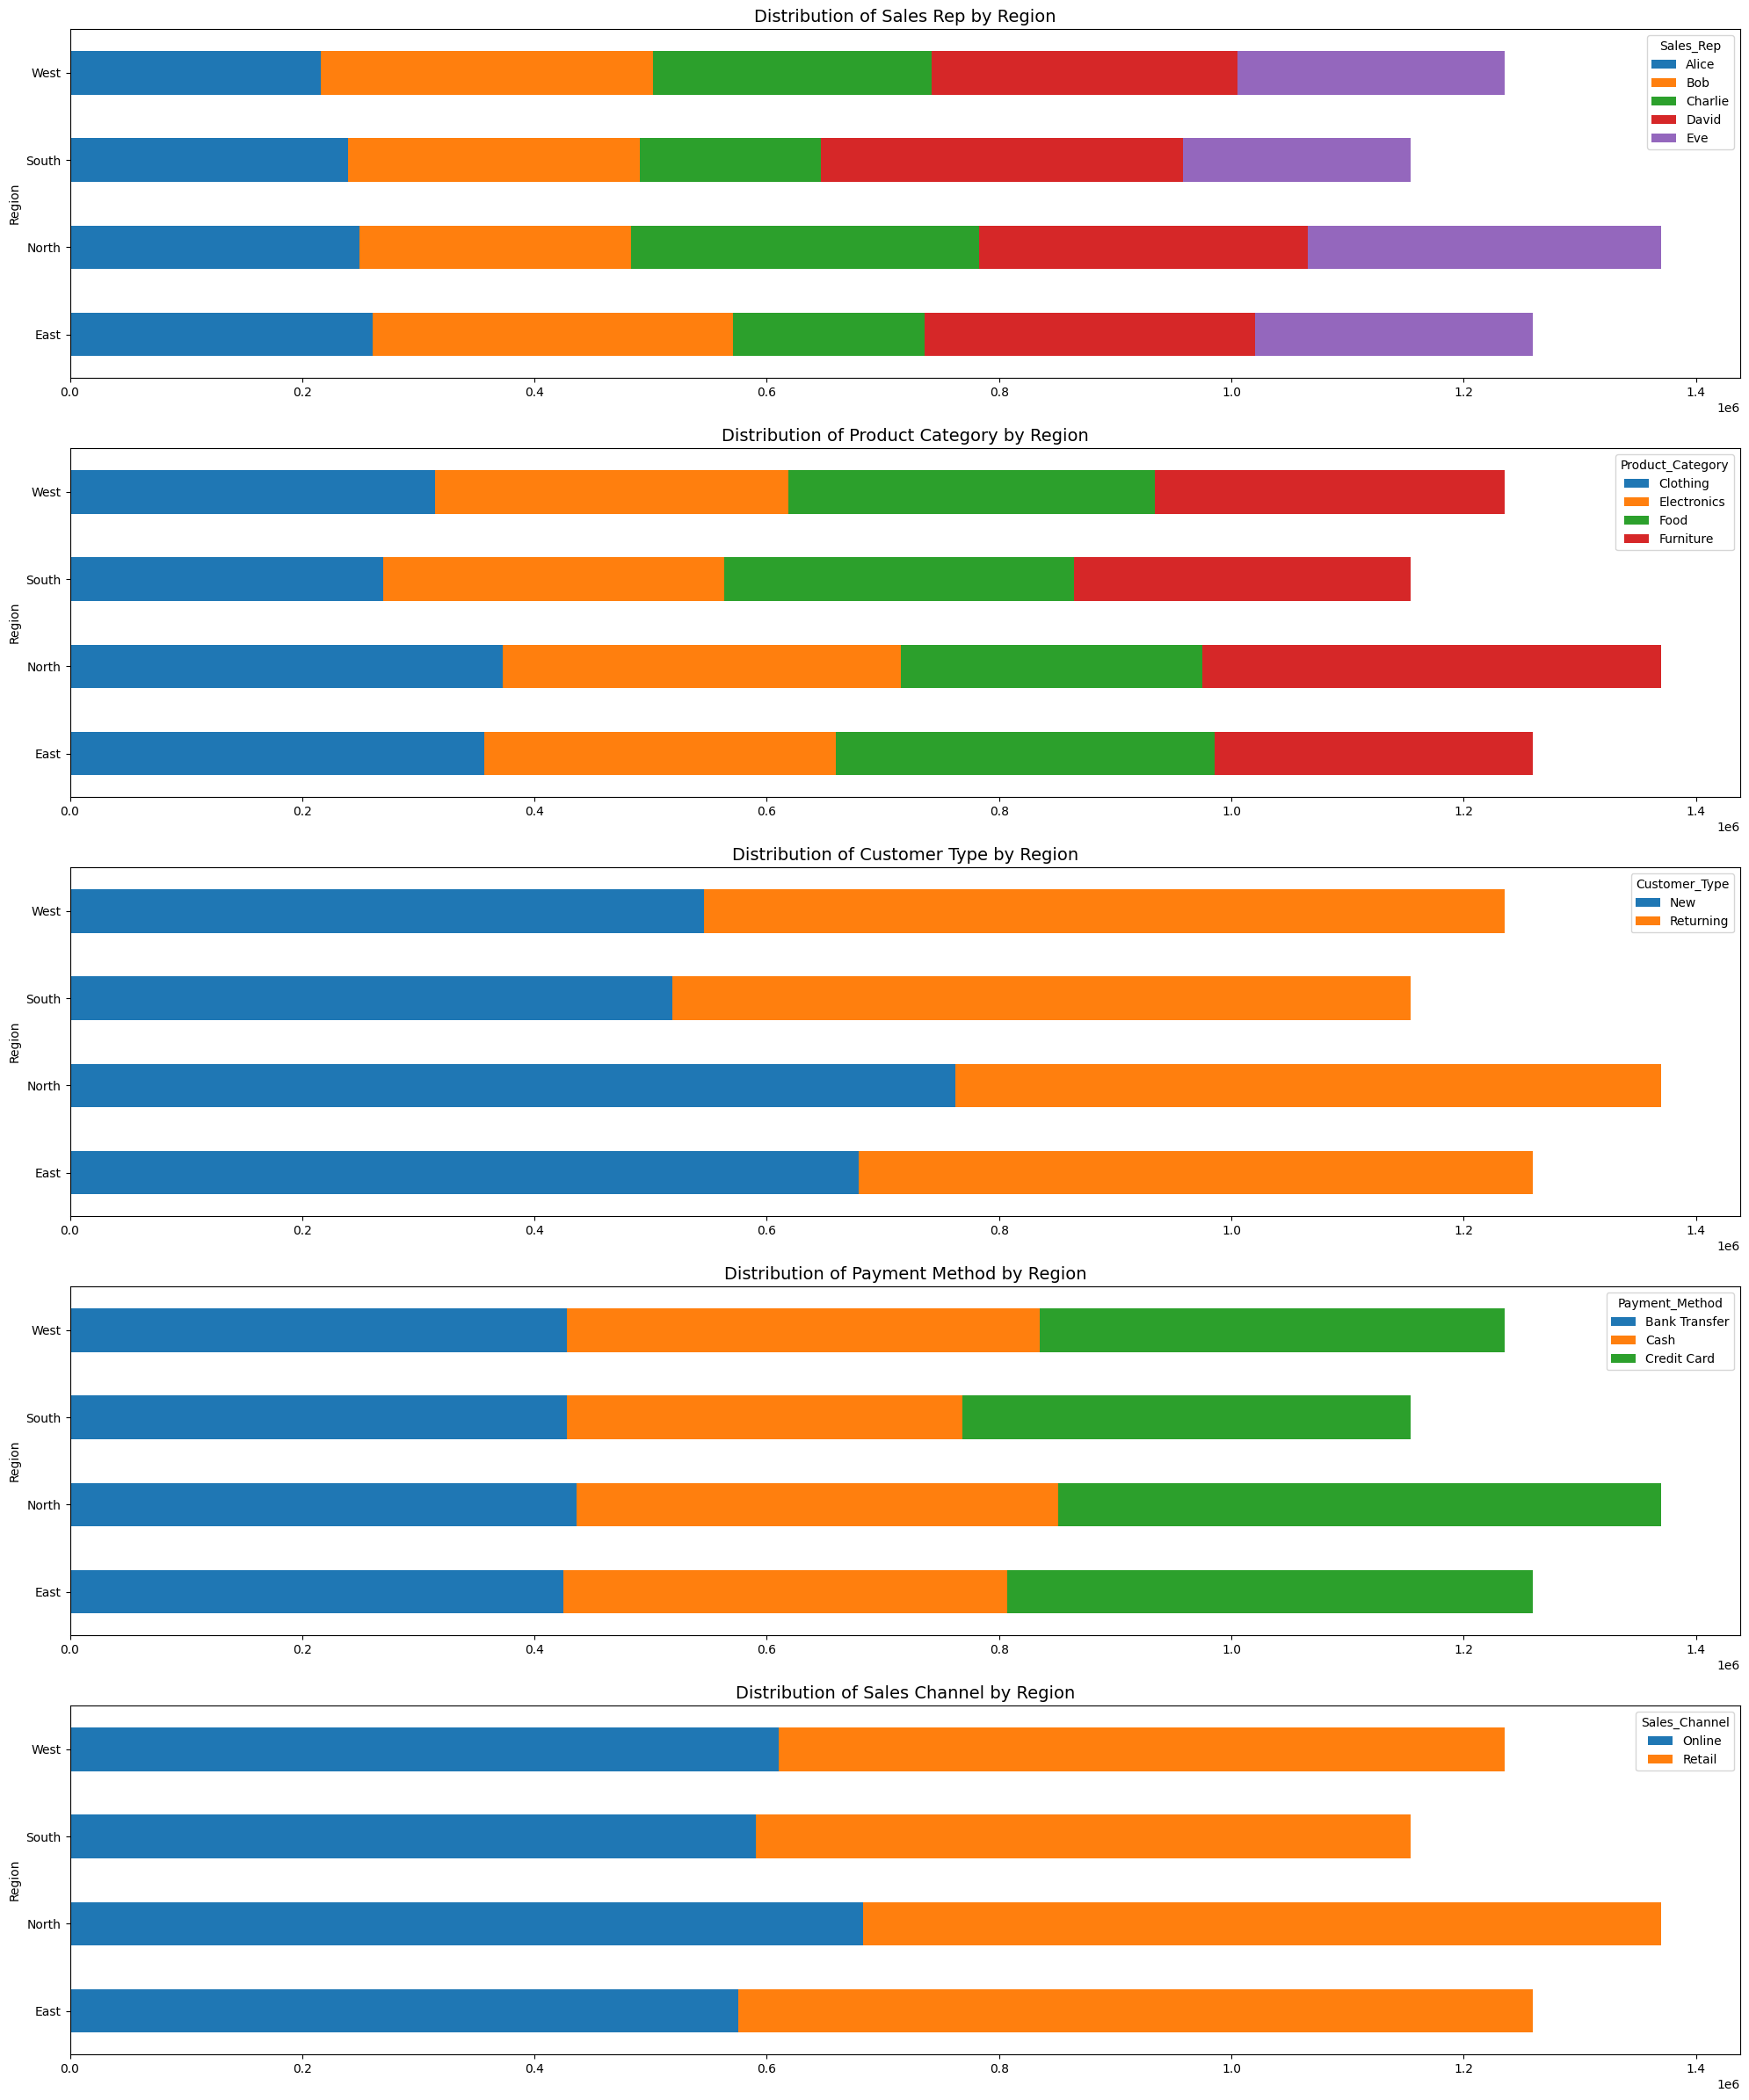

In [11]:
# Group by Region, hue=Rep/Product Category/Customer Type/Payment Method/Sales Channel

fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(20, 24))
ax = ax.flatten()

for i, hue in enumerate(['Sales_Rep', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel']):
    plot_data = data.groupby(['Region', hue])['Sales_Amount'].sum().unstack().plot(kind='barh', stacked=True, ax=ax[i])
    ax[i].set_title(f'Distribution of {hue.replace("_", " ").title()} by Region', fontsize=14)
    ax[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# Product ID, Total Cost, Total Revenue, Total Profit, min/max/mea/std of Unit Price, Unit Cost, Unit Sales and Discount
product_summary = data.groupby('Product_ID').agg({
    'Total_Cost': 'sum',
    'Total_Revenue': 'sum',
    'Total_Profit': 'sum',
    'Unit_Price': ['min', 'max', 'mean', 'std'],
    'Unit_Cost': ['min', 'max', 'mean', 'std'],
    'Unit_Sales': ['min', 'max', 'mean', 'std'],
    'Unit_Price_After_Discount': ['min', 'max', 'mean', 'std'],
    'Discount': ['min', 'max', 'mean', 'std']
})

product_summary.columns = ['_'.join(col).strip() for col in product_summary.columns.values]
product_summary.reset_index(inplace=True)
product_summary.head(10)

,Product_ID,Total_Cost_sum,Total_Revenue_sum,Total_Profit_sum,Unit_Price_min,Unit_Price_max,Unit_Price_mean,Unit_Price_std,Unit_Cost_min,Unit_Cost_max,...,Unit_Sales_mean,Unit_Sales_std,Unit_Price_After_Discount_min,Unit_Price_After_Discount_max,Unit_Price_After_Discount_mean,Unit_Price_After_Discount_std,Discount_min,Discount_max,Discount_mean,Discount_std
0,1001,890419.20,1012319.51,121900.31,682.24,5316.13,2670.316875,1313.216839,442.11,4865.33,...,494.765782,770.777911,573.0816,4997.1622,2323.126781,1165.084164,0.01,0.30,0.129375,0.096986
1,1002,677096.00,745910.34,68814.34,557.69,4784.28,2614.109231,1583.099264,117.63,4646.55,...,272.589553,204.624220,434.9982,4305.8520,2282.687108,1503.265788,0.04,0.28,0.156154,0.081500
2,1003,699326.72,750608.69,51281.97,457.84,5227.93,2778.828333,1600.153028,310.96,4974.14,...,468.827117,599.395991,444.1048,4130.0647,2237.801033,1247.884613,0.03,0.28,0.174167,0.087745
3,1004,791616.11,865859.72,74243.61,211.18,5088.06,3393.677273,1644.008151,182.99,4881.63,...,1269.681145,2256.366953,154.1614,4585.2534,2934.396182,1452.096884,0.05,0.27,0.152727,0.073497
4,1005,599093.05,657473.62,58380.57,385.83,5026.19,2502.542727,1796.814471,122.50,4737.06,...,368.485678,272.552541,347.2470,4818.9500,2273.135055,1639.485636,0.00,0.25,0.095455,0.076729
5,1006,562268.45,617499.20,55230.75,1098.97,4925.17,3210.396250,1444.283765,834.32,4562.58,...,249.435399,258.300214,912.1451,4229.5680,2602.774087,1245.125600,0.04,0.29,0.195000,0.092428
6,1007,432175.75,479002.38,46826.63,1608.76,4633.10,3130.411250,1217.968739,1122.07,4310.31,...,750.111861,1604.358639,1254.8328,3335.8320,2415.018812,787.588237,0.07,0.29,0.208750,0.078274
7,1008,966311.23,1092001.80,125690.57,429.29,5075.44,2599.936154,1476.791794,68.99,4739.13,...,167.411008,100.144425,352.0178,4821.6680,2214.144669,1392.603385,0.03,0.29,0.170000,0.082361
8,1009,463805.00,544961.90,81156.90,733.00,4710.10,2651.391000,1378.140257,359.41,4364.35,...,232.680767,219.507489,586.4000,4380.3930,2272.305460,1202.099555,0.05,0.29,0.139000,0.075638
9,1010,528386.82,561065.85,32679.03,1306.02,5442.15,3609.551667,1523.244828,1150.30,4943.03,...,347.282110,443.488336,1227.6588,4450.9212,3082.926083,1187.269839,0.01,0.29,0.125000,0.102127


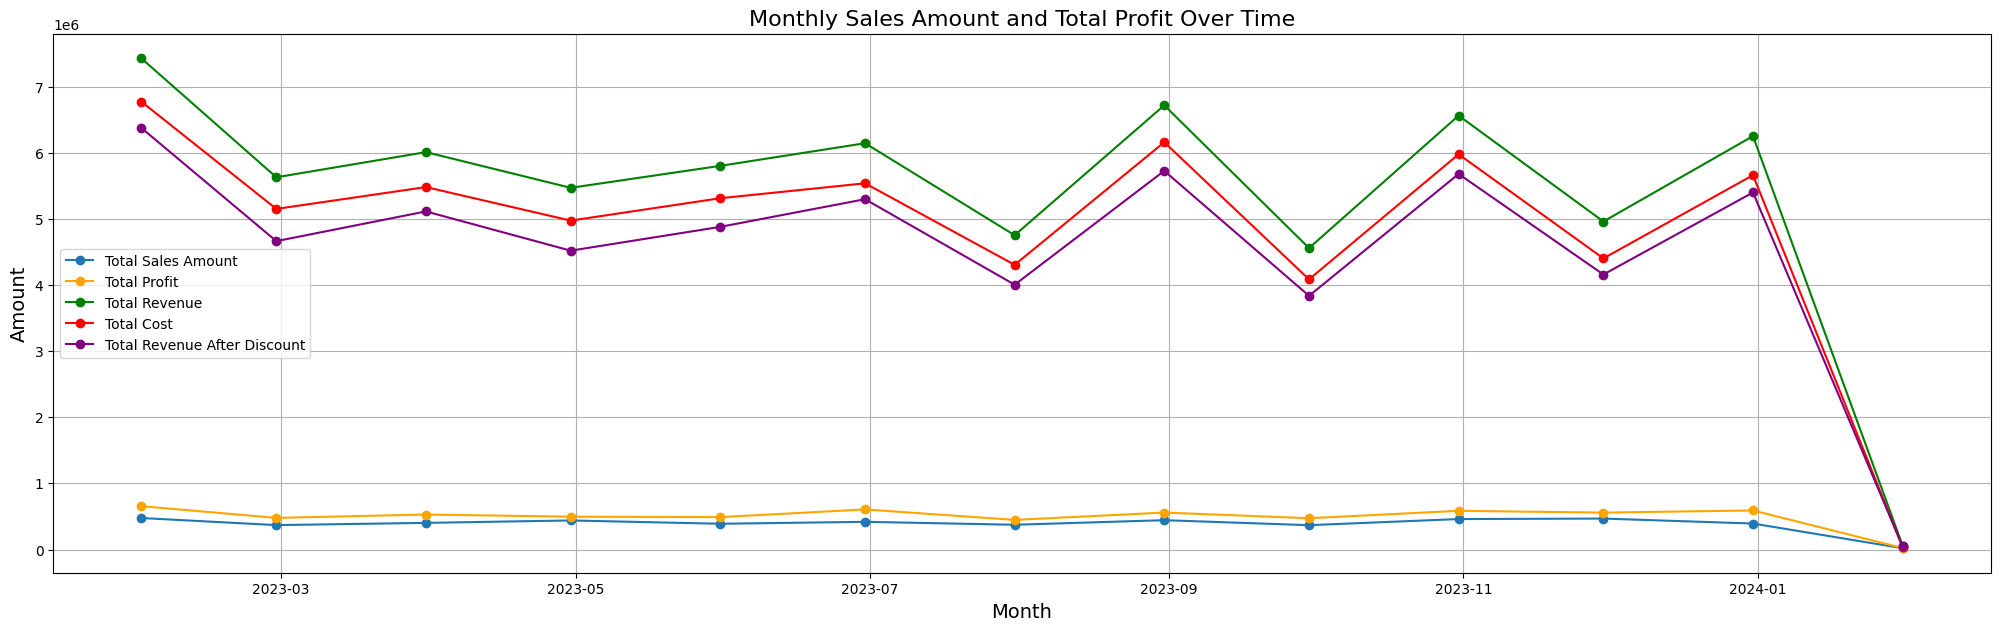

In [21]:
# Time Series Analysis of Sales Amount and Total Profit over Time
data['Sale_Date'] = pd.to_datetime(data['Sale_Date'])
time_series_data = data.set_index('Sale_Date').resample('ME').agg({
    'Sales_Amount': 'sum',
    'Total_Profit': 'sum',
    'Total_Cost': 'sum',
    'Total_Revenue': 'sum',
    'Total_Revenue_After_Discount': 'sum'
}).reset_index()
plt.figure(figsize=(25, 7))

plt.plot(time_series_data['Sale_Date'], time_series_data['Sales_Amount'], marker='o', label='Total Sales Amount')
plt.plot(time_series_data['Sale_Date'], time_series_data['Total_Profit'], marker='o', label='Total Profit', color='orange')
plt.plot(time_series_data['Sale_Date'], time_series_data['Total_Revenue'], marker='o', label='Total Revenue', color='green')
plt.plot(time_series_data['Sale_Date'], time_series_data['Total_Cost'], marker='o', label='Total Cost', color='red')
plt.plot(time_series_data['Sale_Date'], time_series_data['Total_Revenue_After_Discount'], marker='o', label='Total Revenue After Discount', color='purple')

plt.title('Monthly Sales Amount and Total Profit Over Time', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Amount', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [ ]:
pd.crosstab(data['Is_Profitable'], data['Above_Unit_Price'])

Above_Unit_Price,False,True
Is_Profitable,,
False,583,21
True,369,27


In [22]:
data.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep', 'Total_Cost', 'Total_Revenue',
       'Total_Revenue_After_Discount', 'Total_Profit', 'Unit_Sales',
       'Profit_Margin', 'Is_Profitable', 'Above_Unit_Price',
       'Unit_Price_After_Discount'],
      dtype='object')

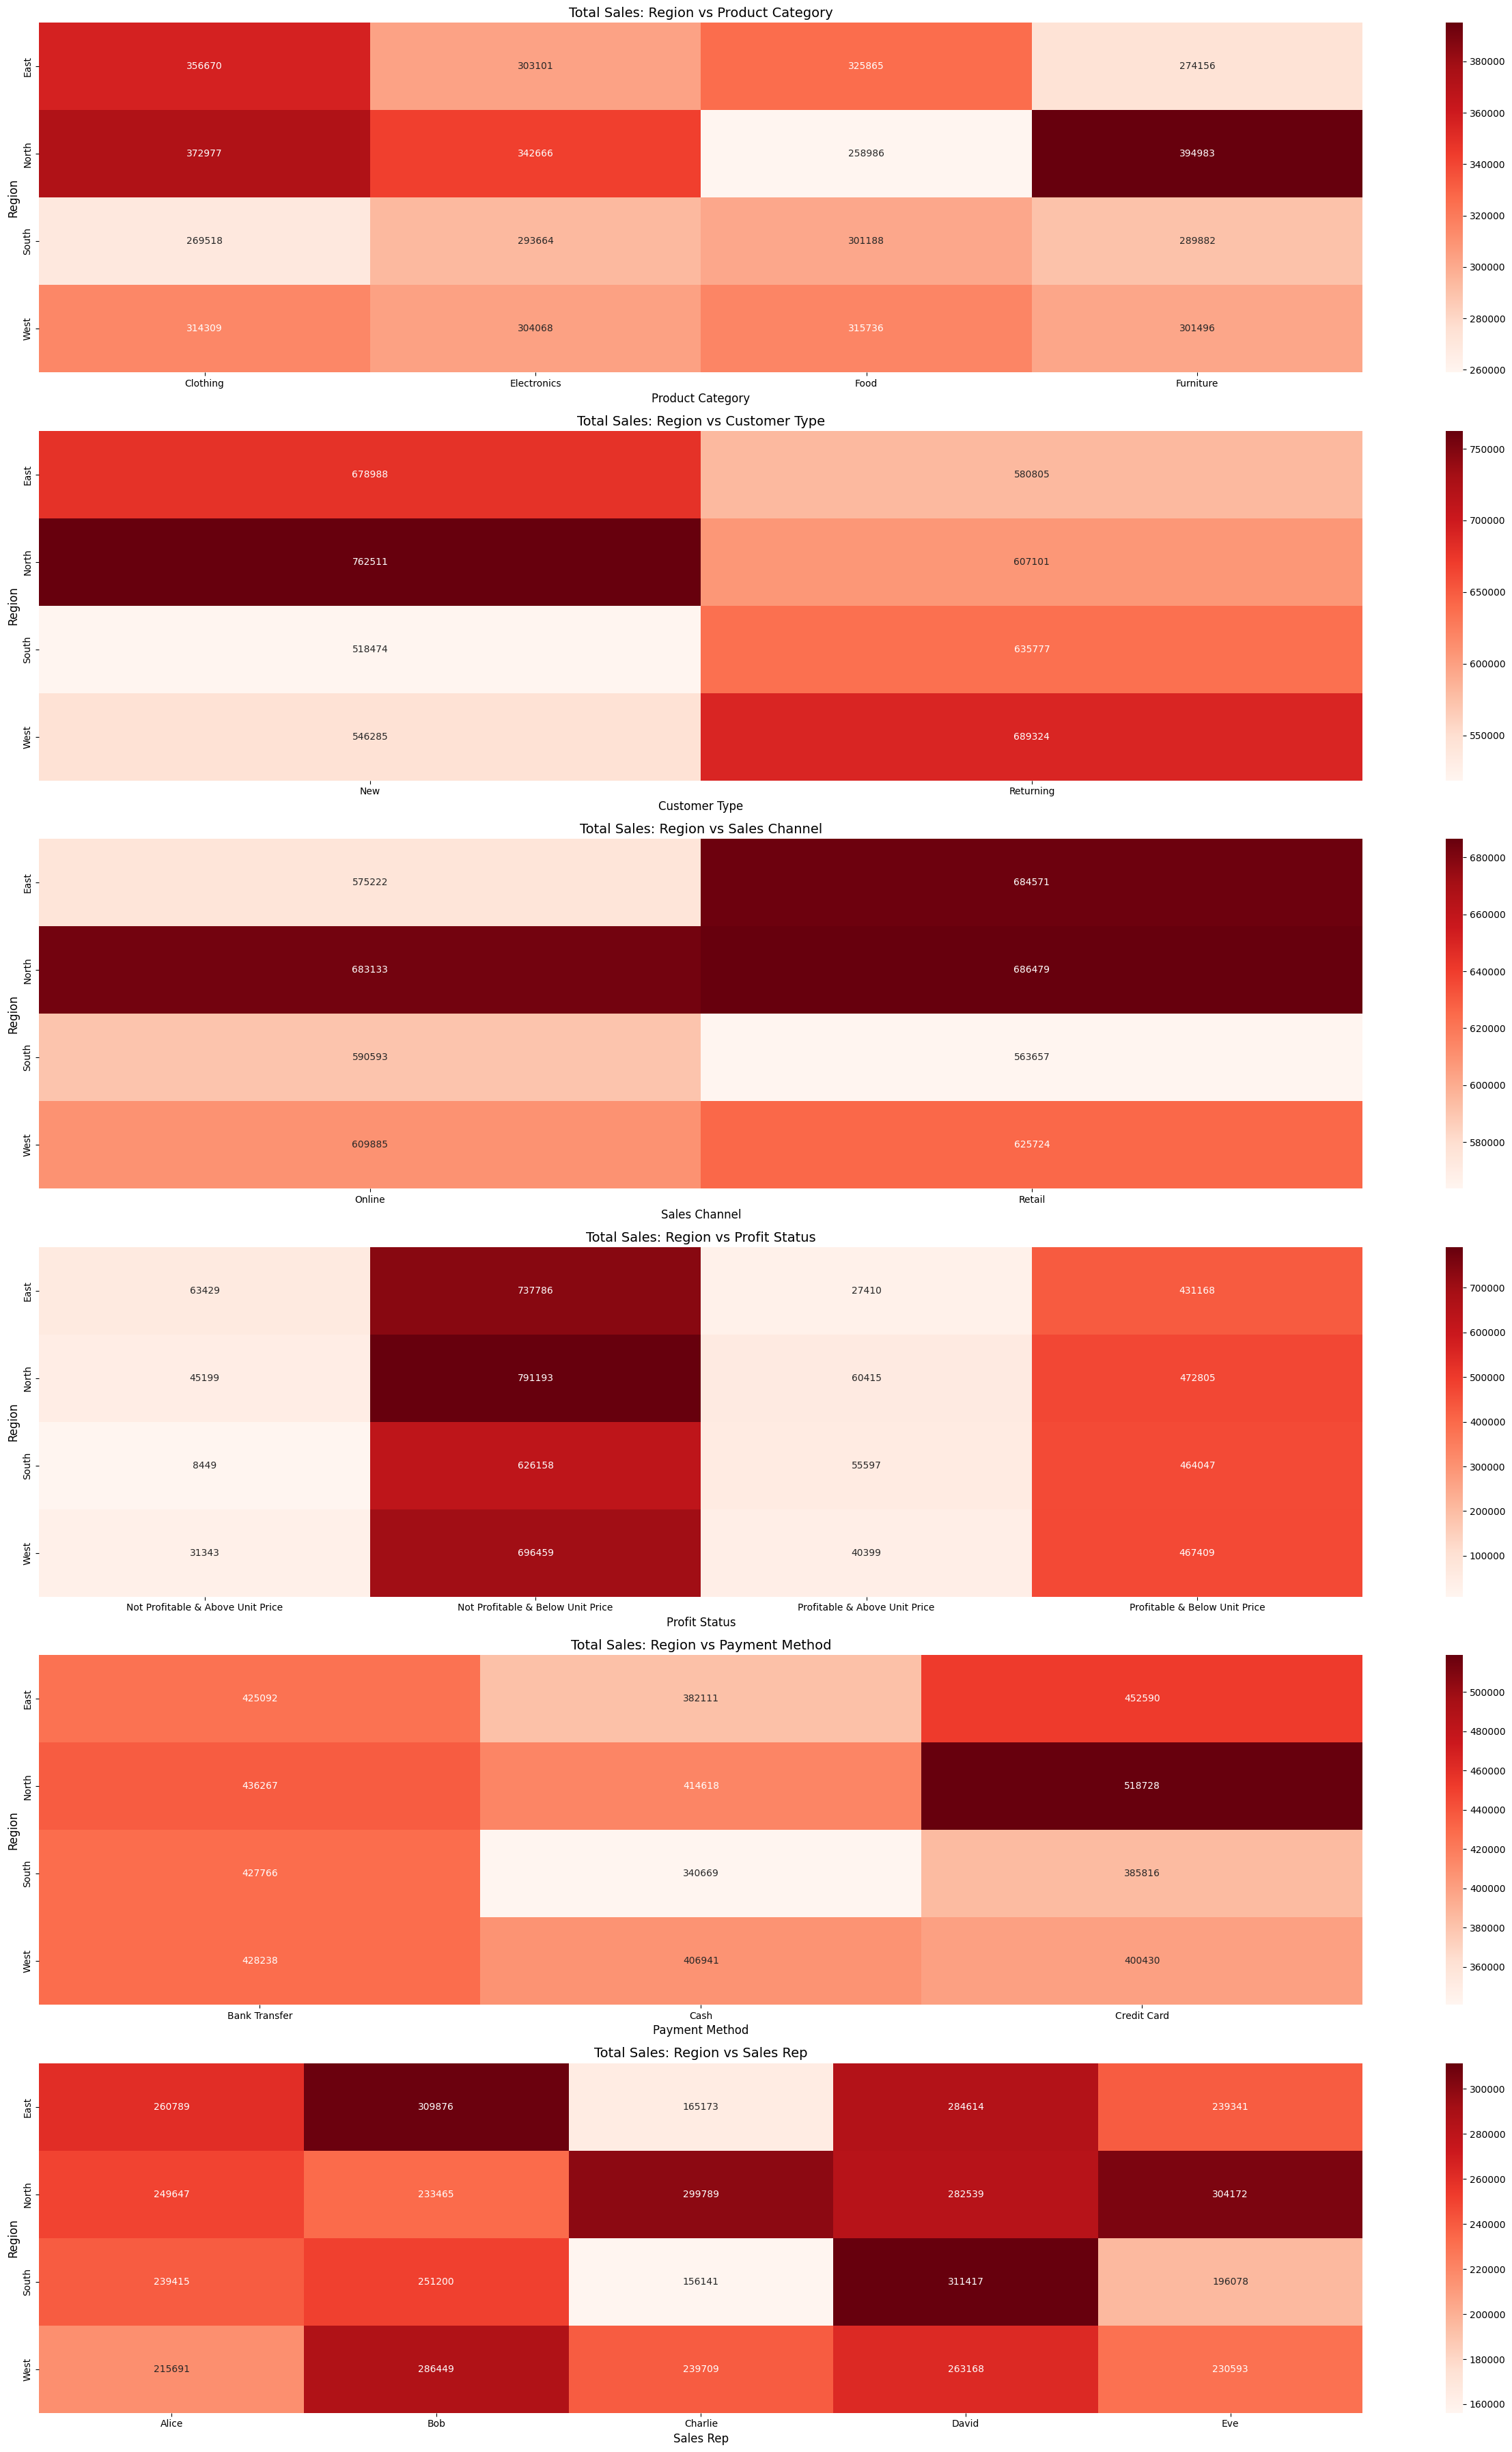

In [38]:
# Select two specific columns to compare
row_var = 'Region'
col_vars = ['Product_Category', 'Customer_Type', 'Sales_Channel', 'Profit_Status', 'Payment_Method', 'Sales_Rep']

fig, axes = plt.subplots(len(col_vars), 1, figsize=(25, 36))

for i, col in enumerate(col_vars):
    # Create the pivot table for Sales_Amount
    pivot = data.pivot_table(index=row_var, columns=col, values='Sales_Amount', aggfunc='sum').fillna(0)
    
    # Plot using Seaborn
    sns.heatmap(pivot, annot=True, fmt='.0f', ax=axes[i], cmap='Reds')
    axes[i].set_title(f'Total Sales: {row_var} vs {col.replace("_", " ")}', fontsize=14)
    axes[i].set_ylabel(row_var, fontsize=12)
    axes[i].set_xlabel(col.replace("_", " "), fontsize=12)

plt.tight_layout()
plt.show()